# 54 - 顔クラスタリング: 自動人物グループ化

全顔 Embedding に対して教師なしクラスタリングを適用し、
自動的に人物グループを発見する。

## 入力
- `data/images.duckdb` (face_detections テーブル)

## 出力
- クラスタリング結果の分析
- `face_detections` テーブルの `cluster_id` 更新

## 手法
- **DBSCAN**: 密度ベース、クラスタ数指定不要、ノイズ検出あり
- **Agglomerative Clustering**: 階層的、距離閾値ベース

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

## 設定

In [2]:
DB_PATH = Path("../data/images.duckdb")
EMBEDDING_DIM = 512

## 顔 Embedding の読み込み

In [3]:
conn = duckdb.connect(str(DB_PATH), read_only=True)

# 全顔データを取得
face_data = conn.execute("""
    SELECT 
        f.face_id, f.image_id, f.embedding, f.det_score,
        f.bbox_x1, f.bbox_y1, f.bbox_x2, f.bbox_y2,
        c.file_name, c.file_path, c.category
    FROM face_detections f
    JOIN image_catalog c ON f.image_id = c.id
    ORDER BY c.category, c.file_name
""").fetchdf()

print(f"総顔数: {len(face_data)}")
print(f"カテゴリ別:")
display(face_data.groupby("category").size().reset_index(name="count"))

# Embedding を numpy 配列に変換
embeddings = np.array(face_data["embedding"].tolist())
print(f"\nEmbedding shape: {embeddings.shape}")

総顔数: 691
カテゴリ別:


,category,count
0,EuroPython2025,345
1,KashiwaVillagePark2026,1
2,PyConJP2025,294
3,PyConJP2025-PreCampHiroshima,37
4,TokyoNight202505,4
5,terada,10



Embedding shape: (691, 512)


In [4]:
conn.close()

## 手法1: DBSCAN

DBSCAN は密度ベースのクラスタリングで、クラスタ数を事前に指定する必要がない。
ノイズ点（どのクラスタにも属さない顔）を自動的に検出する。

コサイン距離を使うため、`metric='precomputed'` で距離行列を渡す。

In [5]:
# コサイン距離行列を計算
# cosine_distance = 1 - cosine_similarity
cos_sim = embeddings @ embeddings.T
cos_dist = 1.0 - cos_sim
np.fill_diagonal(cos_dist, 0)  # 対角は0
cos_dist = np.clip(cos_dist, 0, 2)  # 数値誤差で負になる場合の対策

print(f"距離行列: shape={cos_dist.shape}")
print(f"距離の範囲: [{cos_dist.min():.4f}, {cos_dist.max():.4f}]")
print(f"平均距離: {cos_dist[np.triu_indices_from(cos_dist, k=1)].mean():.4f}")

距離行列: shape=(691, 691)
距離の範囲: [0.0000, 1.2245]
平均距離: 0.9712


In [6]:
# 複数の eps 値で DBSCAN を実行
eps_values = [0.4, 0.5, 0.6, 0.7, 0.8]
dbscan_results = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=2, metric="precomputed")
    labels = dbscan.fit_predict(cos_dist)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()

    # terada の顔がどのクラスタに入ったか
    terada_mask = face_data["category"] == "terada"
    terada_labels = set(labels[terada_mask])
    terada_in_one_cluster = len(terada_labels - {-1}) == 1

    # シルエットスコア (ノイズ除外)
    non_noise = labels != -1
    sil = silhouette_score(cos_dist[non_noise][:, non_noise], labels[non_noise],
                           metric="precomputed") if non_noise.sum() > 1 and len(set(labels[non_noise])) > 1 else 0

    dbscan_results.append({
        "eps": eps,
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "noise_ratio": n_noise / len(labels),
        "silhouette": sil,
        "terada_clusters": terada_labels - {-1},
        "terada_unified": terada_in_one_cluster,
        "labels": labels,
    })

    print(f"eps={eps}: クラスタ数={n_clusters}, ノイズ={n_noise} ({n_noise/len(labels)*100:.0f}%), "
          f"シルエット={sil:.3f}, terada統合={terada_in_one_cluster}")

df_dbscan = pd.DataFrame([{k: v for k, v in r.items() if k != "labels"} for r in dbscan_results])
display(df_dbscan)

eps=0.4: クラスタ数=60, ノイズ=455 (66%), シルエット=0.539, terada統合=True
eps=0.5: クラスタ数=79, ノイズ=370 (54%), シルエット=0.465, terada統合=True
eps=0.6: クラスタ数=101, ノイズ=244 (35%), シルエット=0.367, terada統合=True
eps=0.7: クラスタ数=91, ノイズ=146 (21%), シルエット=0.205, terada統合=True
eps=0.8: クラスタ数=21, ノイズ=52 (8%), シルエット=-0.016, terada統合=True


,eps,n_clusters,n_noise,noise_ratio,silhouette,terada_clusters,terada_unified
0,0.4,60,455,0.658466,0.539402,{0},True
1,0.5,79,370,0.535456,0.465188,{0},True
2,0.6,101,244,0.353111,0.367095,{0},True
3,0.7,91,146,0.211288,0.205345,{0},True
4,0.8,21,52,0.075253,-0.015579,{0},True


## 手法2: Agglomerative Clustering

階層的クラスタリングでコサイン距離を使用。距離閾値でクラスタ数を自動決定する。

In [7]:
# 複数の距離閾値で Agglomerative Clustering を実行
dist_thresholds = [0.5, 0.6, 0.7, 0.8, 0.9]
agglo_results = []

for dt in dist_thresholds:
    agglo = AgglomerativeClustering(
        n_clusters=None,
        distance_threshold=dt,
        metric="precomputed",
        linkage="average",
    )
    labels = agglo.fit_predict(cos_dist)

    n_clusters = len(set(labels))
    # 1つの要素しかないクラスタ = 実質ノイズ
    cluster_sizes = pd.Series(labels).value_counts()
    n_singletons = (cluster_sizes == 1).sum()

    # terada の顔がどのクラスタに入ったか
    terada_mask = face_data["category"] == "terada"
    terada_labels = set(labels[terada_mask])
    terada_in_one_cluster = len(terada_labels) == 1

    # シルエットスコア
    sil = silhouette_score(cos_dist, labels, metric="precomputed") if n_clusters > 1 else 0

    agglo_results.append({
        "threshold": dt,
        "n_clusters": n_clusters,
        "n_singletons": n_singletons,
        "silhouette": sil,
        "terada_clusters": terada_labels,
        "terada_unified": terada_in_one_cluster,
        "labels": labels,
    })

    print(f"threshold={dt}: クラスタ数={n_clusters}, 単独={n_singletons}, "
          f"シルエット={sil:.3f}, terada統合={terada_in_one_cluster}")

df_agglo = pd.DataFrame([{k: v for k, v in r.items() if k != "labels"} for r in agglo_results])
display(df_agglo)

threshold=0.5: クラスタ数=481, 単独=391, シルエット=0.180, terada統合=True
threshold=0.6: クラスタ数=403, 単独=282, シルエット=0.208, terada統合=True
threshold=0.7: クラスタ数=317, 単独=176, シルエット=0.230, terada統合=True
threshold=0.8: クラスタ数=243, 単独=97, シルエット=0.235, terada統合=True
threshold=0.9: クラスタ数=105, 単独=2, シルエット=0.171, terada統合=True


,threshold,n_clusters,n_singletons,silhouette,terada_clusters,terada_unified
0,0.5,481,391,0.179784,{59},True
1,0.6,403,282,0.207583,{120},True
2,0.7,317,176,0.229565,{120},True
3,0.8,243,97,0.234951,{242},True
4,0.9,105,2,0.170882,{27},True


## 手法の比較と最適パラメータの選択

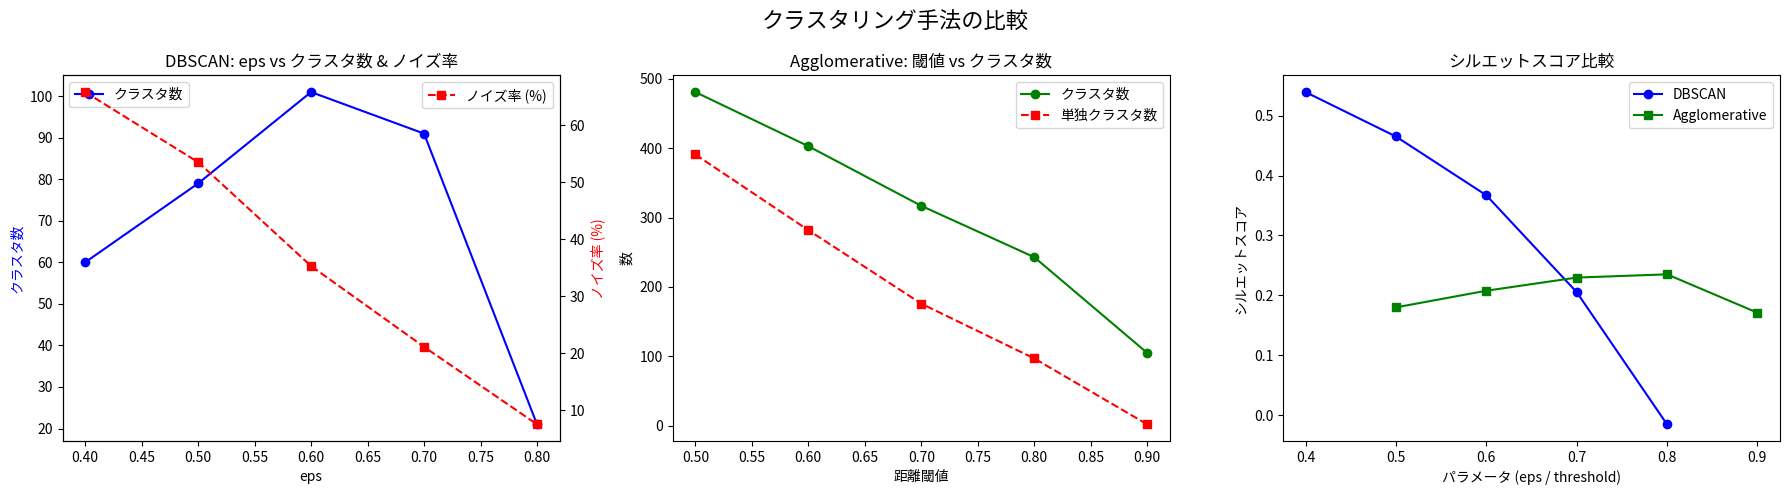

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# DBSCAN: eps vs クラスタ数 & ノイズ率
ax1 = axes[0]
ax1_twin = ax1.twinx()
ax1.plot(df_dbscan["eps"], df_dbscan["n_clusters"], "b-o", label="クラスタ数")
ax1_twin.plot(df_dbscan["eps"], df_dbscan["noise_ratio"] * 100, "r--s", label="ノイズ率 (%)")
ax1.set_title("DBSCAN: eps vs クラスタ数 & ノイズ率")
ax1.set_xlabel("eps")
ax1.set_ylabel("クラスタ数", color="blue")
ax1_twin.set_ylabel("ノイズ率 (%)", color="red")
ax1.legend(loc="upper left")
ax1_twin.legend(loc="upper right")

# Agglomerative: threshold vs クラスタ数
axes[1].plot(df_agglo["threshold"], df_agglo["n_clusters"], "g-o", label="クラスタ数")
axes[1].plot(df_agglo["threshold"], df_agglo["n_singletons"], "r--s", label="単独クラスタ数")
axes[1].set_title("Agglomerative: 閾値 vs クラスタ数")
axes[1].set_xlabel("距離閾値")
axes[1].set_ylabel("数")
axes[1].legend()

# シルエットスコア比較
axes[2].plot(df_dbscan["eps"], df_dbscan["silhouette"], "b-o", label="DBSCAN")
axes[2].plot(df_agglo["threshold"], df_agglo["silhouette"], "g-s", label="Agglomerative")
axes[2].set_title("シルエットスコア比較")
axes[2].set_xlabel("パラメータ (eps / threshold)")
axes[2].set_ylabel("シルエットスコア")
axes[2].legend()

plt.suptitle("クラスタリング手法の比較", fontsize=16)
plt.tight_layout()
plt.show()

In [9]:
# 最良の結果を選択（terada が統合され、シルエットが高いもの）
# DBSCAN から terada_unified=True のものを優先
best_dbscan = None
for r in dbscan_results:
    if r["terada_unified"]:
        if best_dbscan is None or r["silhouette"] > best_dbscan["silhouette"]:
            best_dbscan = r

best_agglo = None
for r in agglo_results:
    if r["terada_unified"]:
        if best_agglo is None or r["silhouette"] > best_agglo["silhouette"]:
            best_agglo = r

# 最終選択
if best_dbscan and (not best_agglo or best_dbscan["silhouette"] >= best_agglo["silhouette"]):
    best_labels = best_dbscan["labels"]
    best_method = f"DBSCAN (eps={best_dbscan['eps']})"
    print(f"最良手法: {best_method}")
    print(f"  クラスタ数: {best_dbscan['n_clusters']}, ノイズ: {best_dbscan['n_noise']}, シルエット: {best_dbscan['silhouette']:.3f}")
elif best_agglo:
    best_labels = best_agglo["labels"]
    best_method = f"Agglomerative (threshold={best_agglo['threshold']})"
    print(f"最良手法: {best_method}")
    print(f"  クラスタ数: {best_agglo['n_clusters']}, シルエット: {best_agglo['silhouette']:.3f}")
else:
    # fallback: DBSCAN の最初の結果
    best_labels = dbscan_results[0]["labels"]
    best_method = f"DBSCAN (eps={dbscan_results[0]['eps']}) [fallback]"
    print(f"最良手法: {best_method} (terada が統合されなかったため fallback)")

face_data["cluster_id"] = best_labels

最良手法: DBSCAN (eps=0.4)
  クラスタ数: 60, ノイズ: 455, シルエット: 0.539


## クラスタサイズ分布

ノイズ（どのクラスタにも属さない顔）: 455
クラスタ数（ノイズ除外）: 60
クラスタサイズ: 最大=42, 最小=2, 平均=3.9


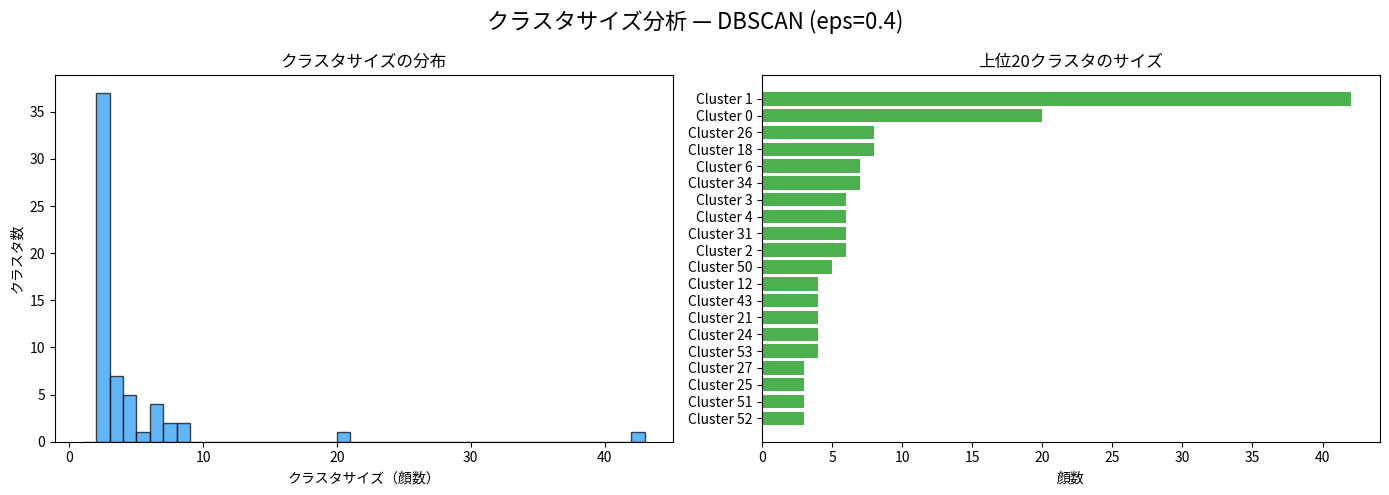

In [10]:
cluster_sizes = face_data["cluster_id"].value_counts().sort_values(ascending=False)

# ノイズ (-1) を別扱い
if -1 in cluster_sizes.index:
    noise_count = cluster_sizes[-1]
    cluster_sizes_no_noise = cluster_sizes.drop(-1)
    print(f"ノイズ（どのクラスタにも属さない顔）: {noise_count}")
else:
    cluster_sizes_no_noise = cluster_sizes

print(f"クラスタ数（ノイズ除外）: {len(cluster_sizes_no_noise)}")
print(f"クラスタサイズ: 最大={cluster_sizes_no_noise.max()}, 最小={cluster_sizes_no_noise.min()}, 平均={cluster_sizes_no_noise.mean():.1f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# クラスタサイズの分布
ax1.hist(cluster_sizes_no_noise.values, bins=range(1, cluster_sizes_no_noise.max() + 2),
         edgecolor="black", alpha=0.7, color="#2196F3")
ax1.set_title("クラスタサイズの分布")
ax1.set_xlabel("クラスタサイズ（顔数）")
ax1.set_ylabel("クラスタ数")

# 上位20クラスタのサイズ
top20 = cluster_sizes_no_noise.head(20)
ax2.barh(range(len(top20)), top20.values, color="#4CAF50")
ax2.set_yticks(range(len(top20)))
ax2.set_yticklabels([f"Cluster {i}" for i in top20.index])
ax2.set_title("上位20クラスタのサイズ")
ax2.set_xlabel("顔数")
ax2.invert_yaxis()

plt.suptitle(f"クラスタサイズ分析 — {best_method}", fontsize=16)
plt.tight_layout()
plt.show()

## Top-10 クラスタの顔グリッド表示

最大のクラスタから順に、各クラスタに属する顔を表示する。
同じクラスタ内の顔が同一人物かどうかを目視で確認する。

In [11]:
def crop_face(file_path: str, bbox_x1: float, bbox_y1: float, bbox_x2: float, bbox_y2: float, padding: int = 20) -> Image.Image:
    """画像から顔をクロップする"""
    img = Image.open(file_path).convert("RGB")
    x1 = max(0, int(bbox_x1) - padding)
    y1 = max(0, int(bbox_y1) - padding)
    x2 = min(img.width, int(bbox_x2) + padding)
    y2 = min(img.height, int(bbox_y2) + padding)
    return img.crop((x1, y1, x2, y2))

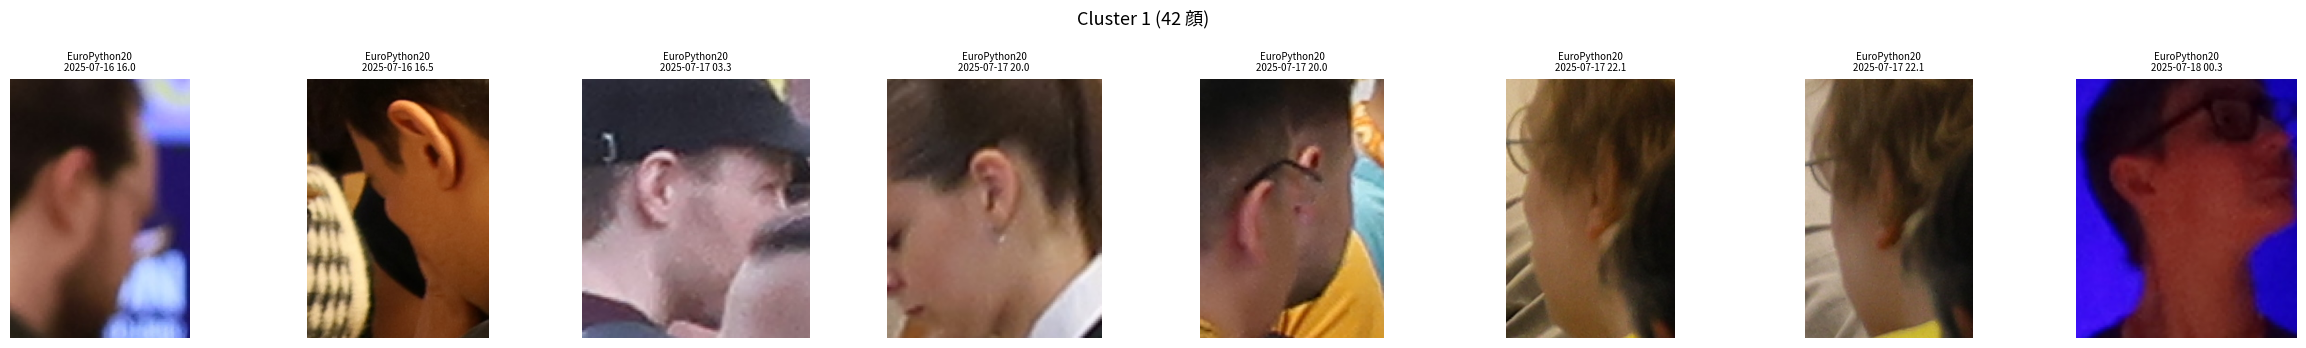

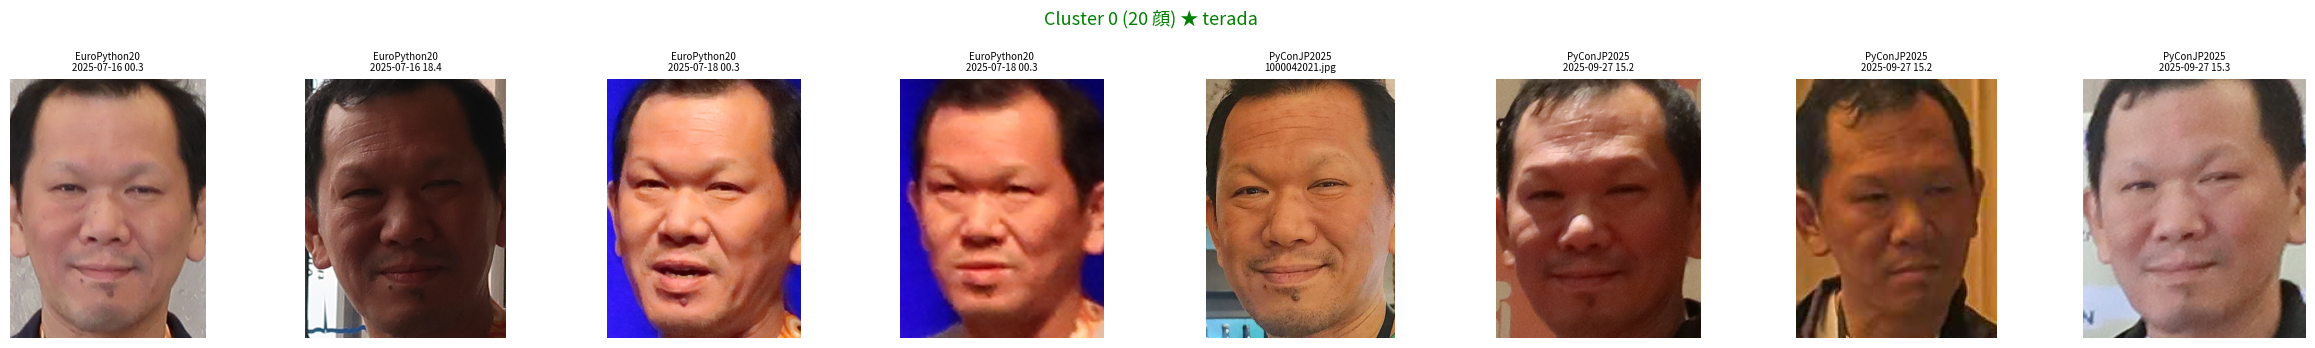

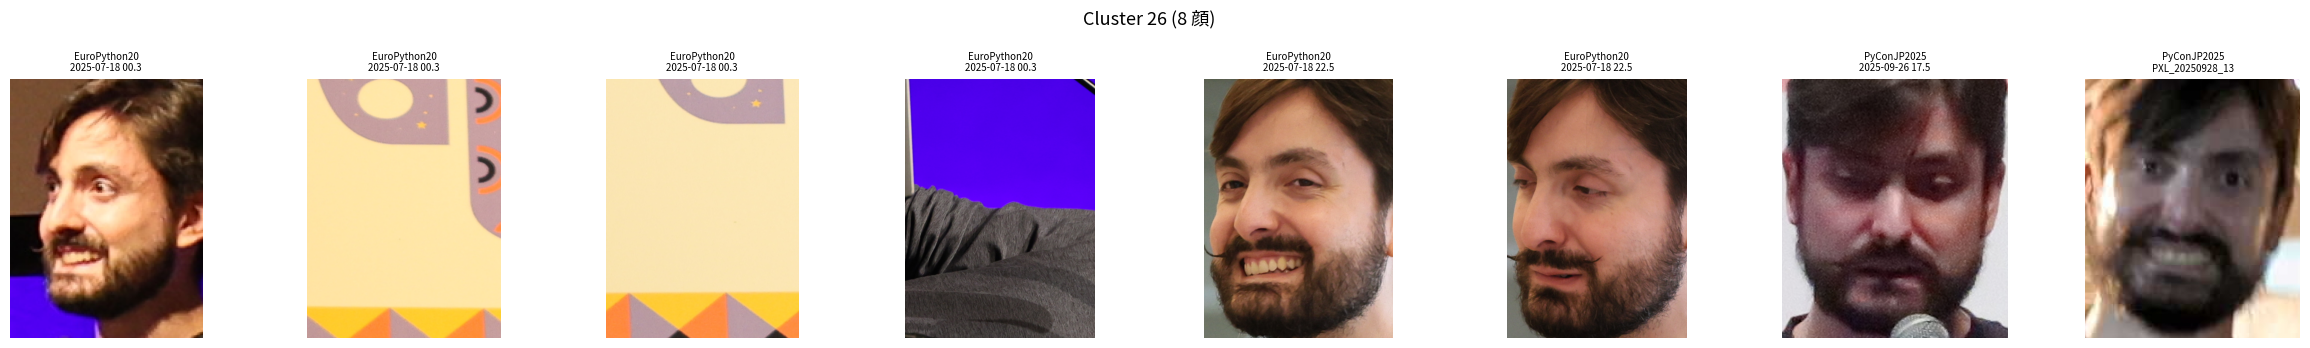

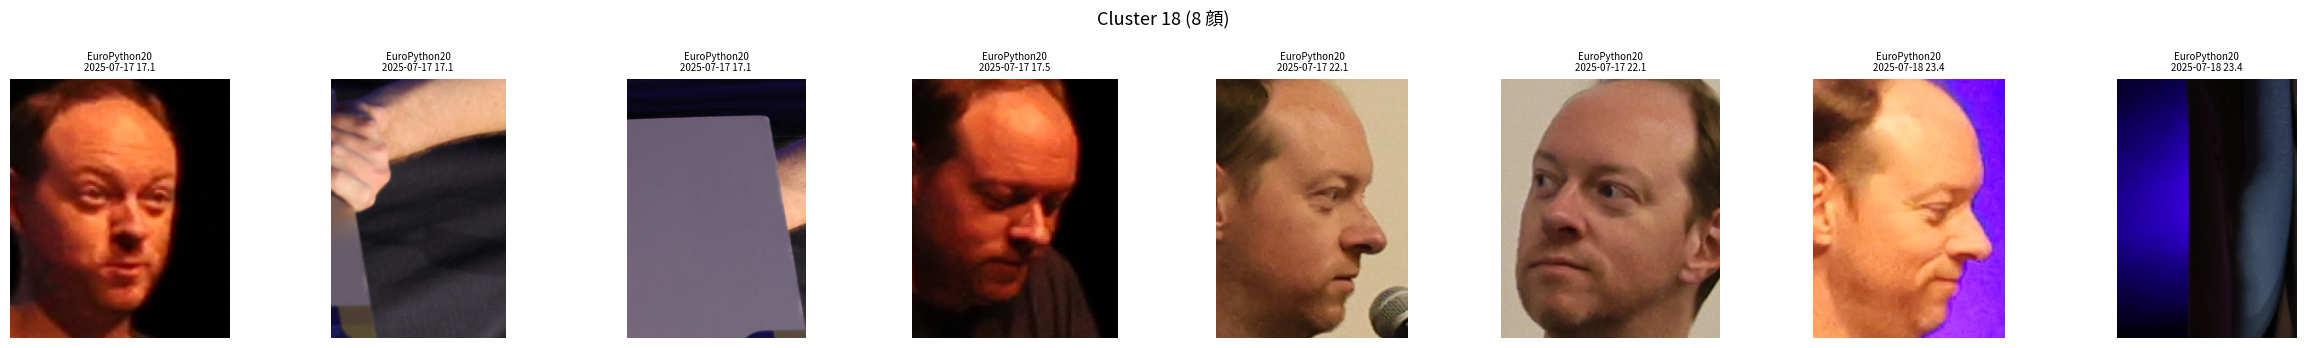

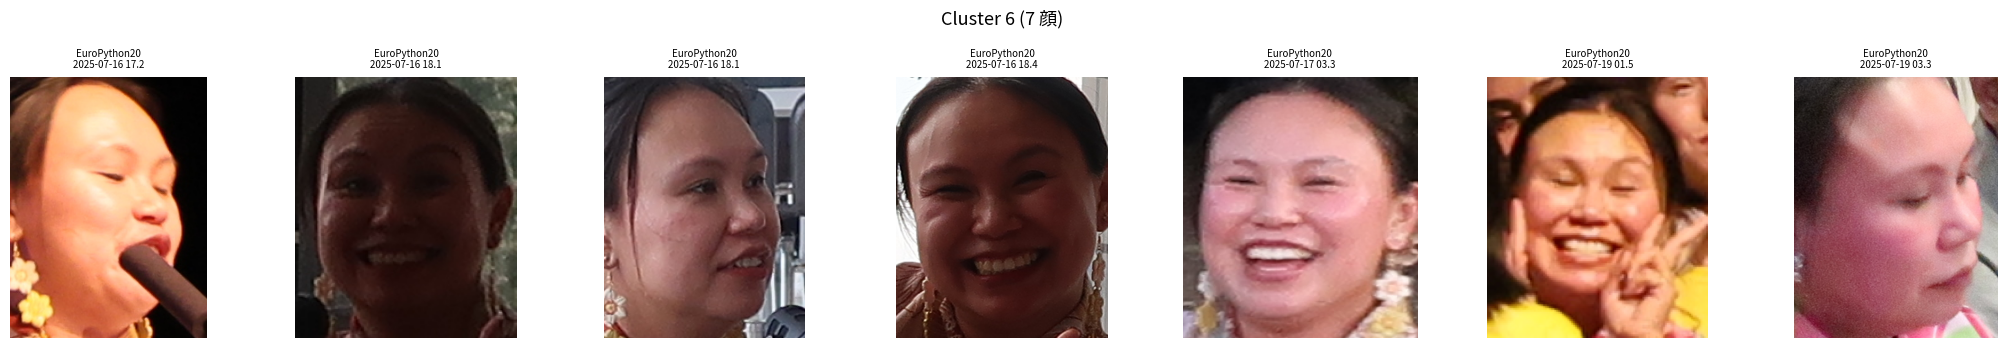

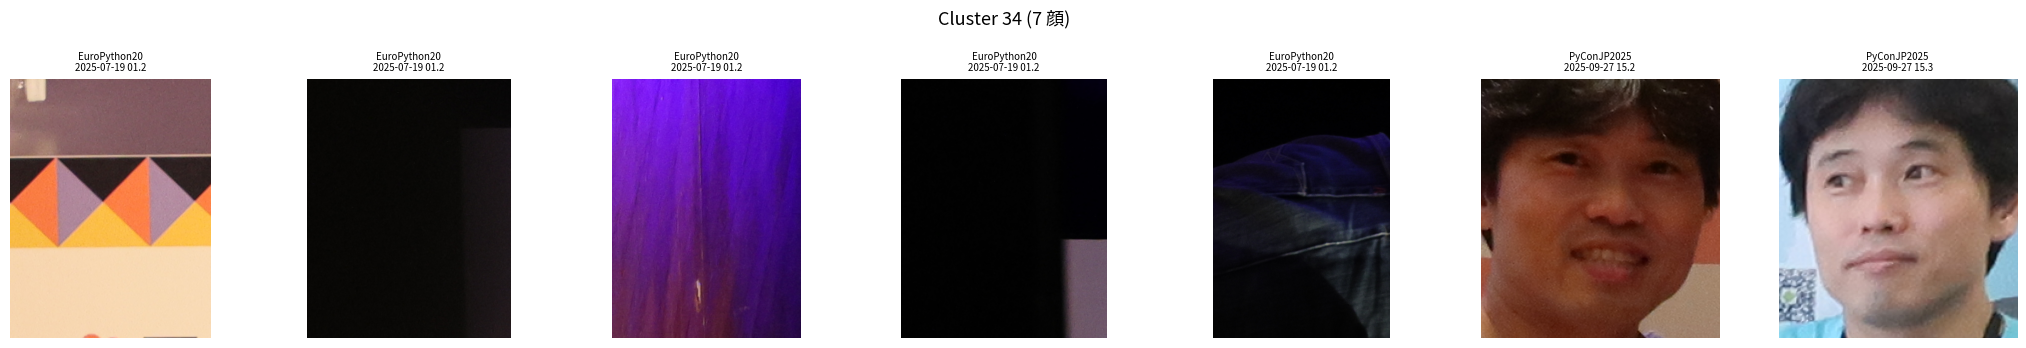

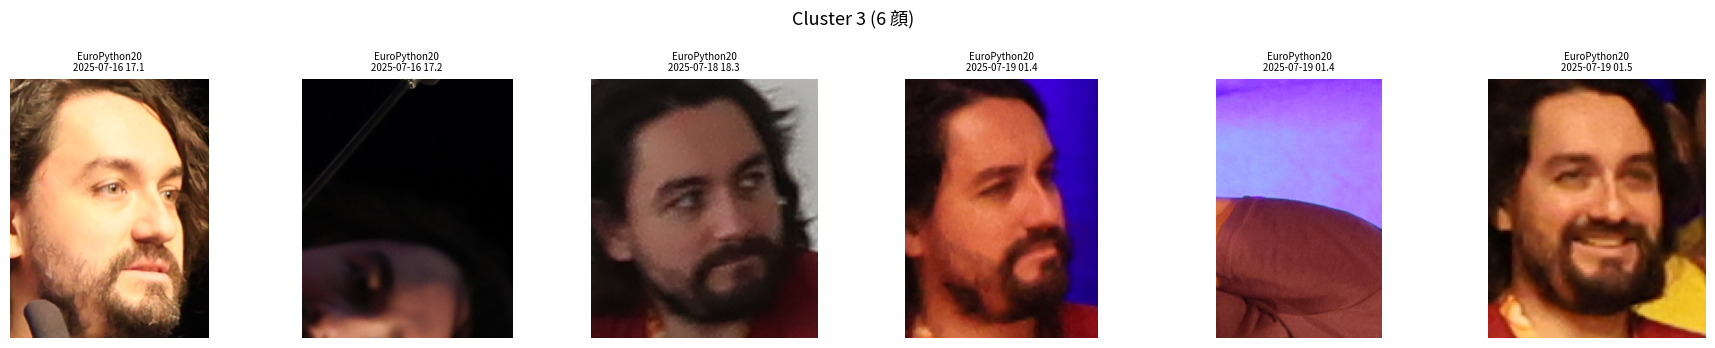

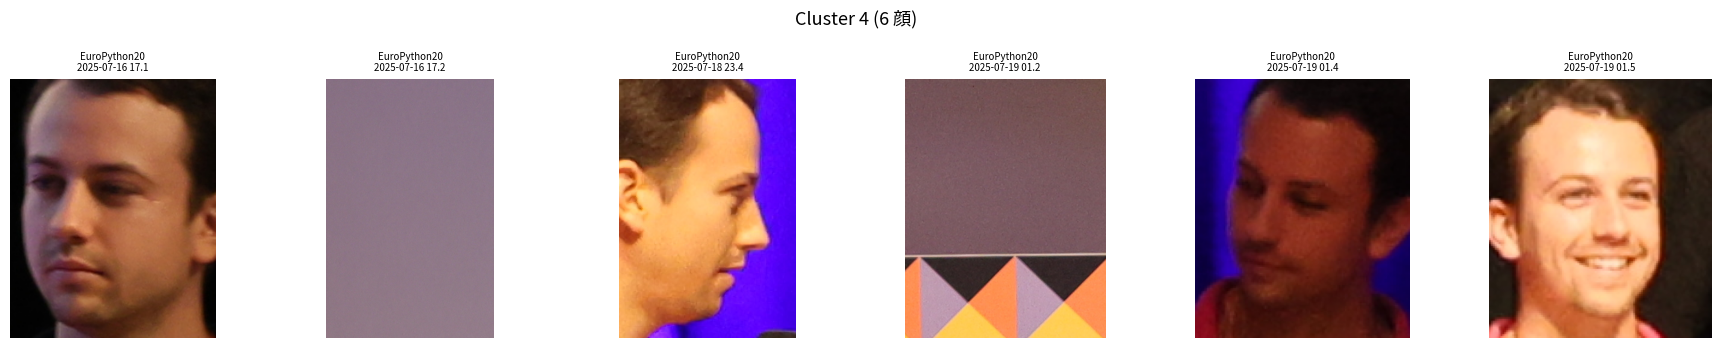

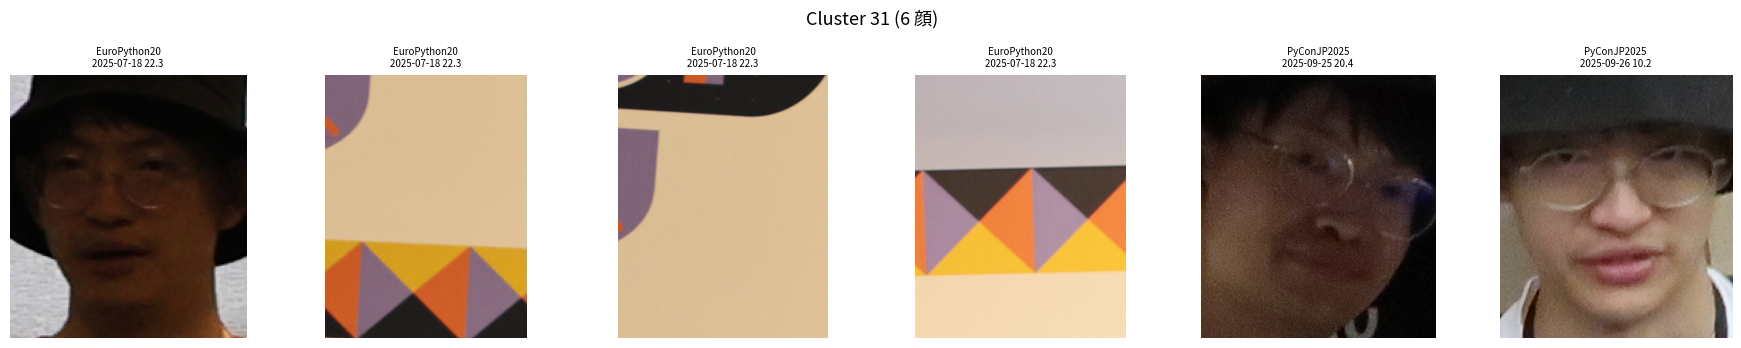

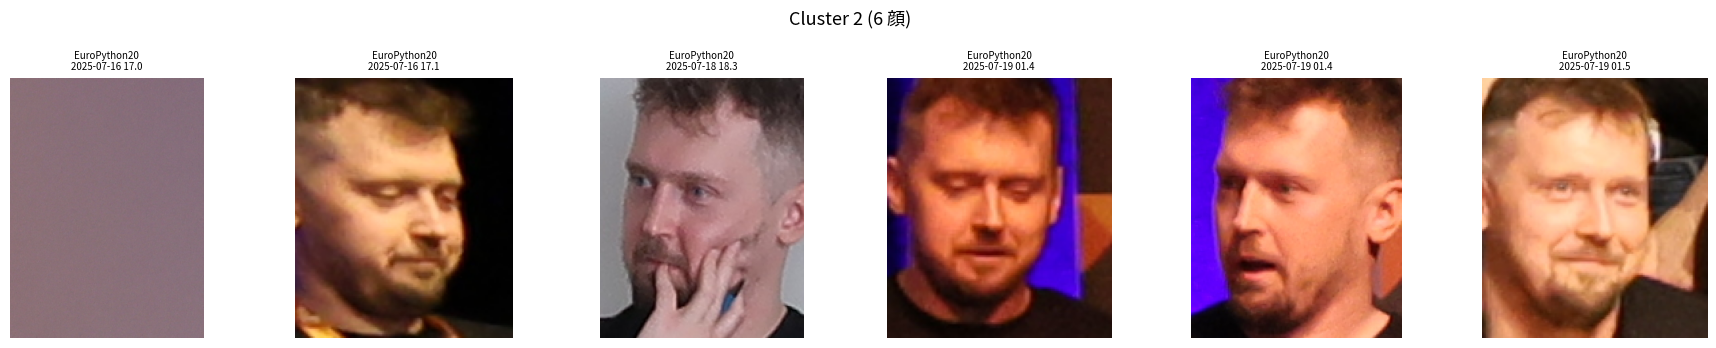

In [12]:
# Top-10 クラスタ（ノイズ除外）
top_clusters = cluster_sizes_no_noise.head(10).index.tolist()
MAX_FACES_PER_CLUSTER = 8

for cluster_id in top_clusters:
    cluster_faces = face_data[face_data["cluster_id"] == cluster_id]
    n_show = min(len(cluster_faces), MAX_FACES_PER_CLUSTER)
    sample = cluster_faces.head(n_show)

    # terada が含まれるかチェック
    has_terada = "terada" in cluster_faces["category"].values
    title_color = "green" if has_terada else "black"
    title_suffix = " ★ terada" if has_terada else ""

    fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 3.5))
    if n_show == 1:
        axes = [axes]

    for idx, (_, row) in enumerate(sample.iterrows()):
        try:
            face_crop = crop_face(row["file_path"], row["bbox_x1"], row["bbox_y1"],
                                  row["bbox_x2"], row["bbox_y2"])
            axes[idx].imshow(face_crop)
        except Exception:
            axes[idx].text(0.5, 0.5, "Error", ha="center", va="center", transform=axes[idx].transAxes)

        cat_label = row["category"][:12]
        axes[idx].set_title(f"{cat_label}\n{row['file_name'][:15]}", fontsize=7)
        axes[idx].axis("off")

    plt.suptitle(
        f"Cluster {cluster_id} ({len(cluster_faces)} 顔){title_suffix}",
        fontsize=13, color=title_color
    )
    plt.tight_layout()
    plt.show()

## t-SNE 可視化

顔 Embedding 空間を2次元に圧縮し、クラスタ構造を可視化する。

In [13]:
print("t-SNE を実行中...")
tsne = TSNE(n_components=2, metric="cosine", random_state=42, perplexity=min(30, len(embeddings) - 1))
tsne_result = tsne.fit_transform(embeddings)
print(f"t-SNE 完了: shape={tsne_result.shape}")

t-SNE を実行中...


t-SNE 完了: shape=(691, 2)


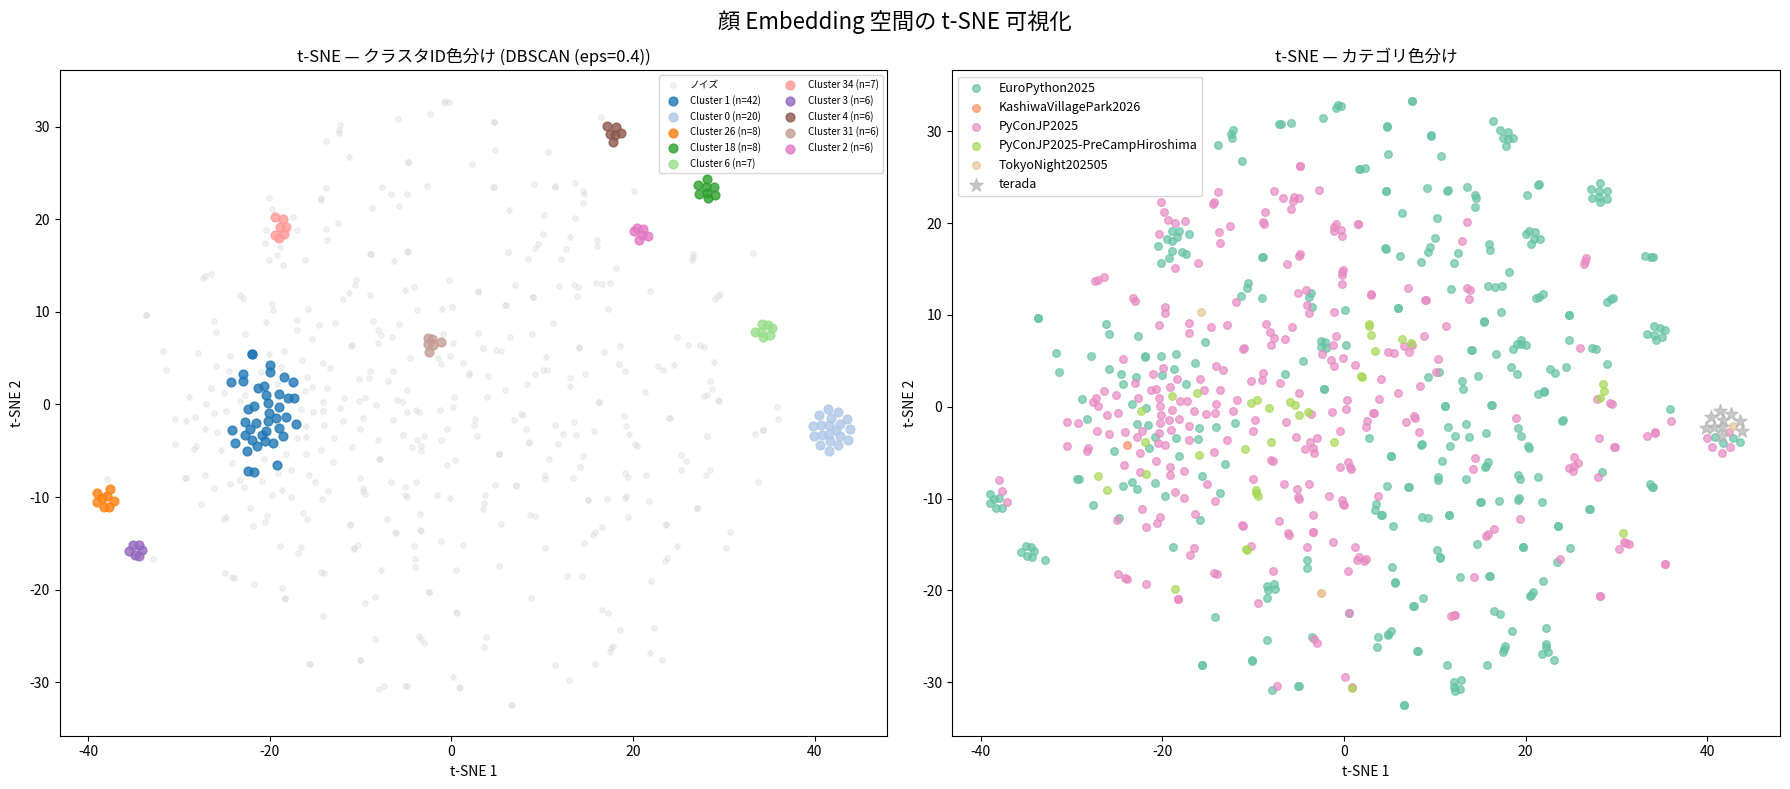

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# 1. クラスタIDで色分け
unique_clusters = sorted(set(best_labels))
# 上位N クラスタに色を割り当て、残りはグレー
n_colored = min(15, len([c for c in unique_clusters if c != -1]))
cmap = plt.cm.tab20(np.linspace(0, 1, n_colored))

# ノイズをまず描画（背面）
noise_mask = best_labels == -1
if noise_mask.any():
    ax1.scatter(tsne_result[noise_mask, 0], tsne_result[noise_mask, 1],
                c="lightgray", s=15, alpha=0.3, label="ノイズ")

# 上位クラスタを描画
for i, cluster_id in enumerate(top_clusters[:n_colored]):
    mask = best_labels == cluster_id
    ax1.scatter(tsne_result[mask, 0], tsne_result[mask, 1],
                c=[cmap[i]], s=40, alpha=0.8, label=f"Cluster {cluster_id} (n={mask.sum()})")

ax1.set_title(f"t-SNE — クラスタID色分け ({best_method})")
ax1.legend(fontsize=7, loc="best", ncol=2)
ax1.set_xlabel("t-SNE 1")
ax1.set_ylabel("t-SNE 2")

# 2. カテゴリで色分け
categories = face_data["category"].unique()
cat_cmap = plt.cm.Set2(np.linspace(0, 1, len(categories)))

for i, cat in enumerate(sorted(categories)):
    mask = face_data["category"] == cat
    marker = "*" if cat == "terada" else "o"
    size = 100 if cat == "terada" else 30
    ax2.scatter(tsne_result[mask.values, 0], tsne_result[mask.values, 1],
                c=[cat_cmap[i]], s=size, alpha=0.7, marker=marker, label=cat)

ax2.set_title("t-SNE — カテゴリ色分け")
ax2.legend(fontsize=9)
ax2.set_xlabel("t-SNE 1")
ax2.set_ylabel("t-SNE 2")

plt.suptitle("顔 Embedding 空間の t-SNE 可視化", fontsize=16)
plt.tight_layout()
plt.show()

## クラスタリング結果を DuckDB に保存

In [15]:
# 書き込みモードで接続
conn_write = duckdb.connect(str(DB_PATH))
conn_write.execute("LOAD vss;")

# cluster_id を更新
updated = 0
for _, row in face_data.iterrows():
    cluster_id = int(row["cluster_id"]) if row["cluster_id"] != -1 else None
    conn_write.execute("""
        UPDATE face_detections
        SET cluster_id = ?
        WHERE face_id = ?
    """, [cluster_id, row["face_id"]])
    updated += 1

conn_write.commit()
print(f"cluster_id を {updated} レコード更新しました")

# 確認
result = conn_write.execute("""
    SELECT cluster_id, COUNT(*) as count
    FROM face_detections
    WHERE cluster_id IS NOT NULL
    GROUP BY cluster_id
    ORDER BY count DESC
    LIMIT 10
""").fetchdf()

print("\nTop 10 クラスタ:")
display(result)

conn_write.close()

cluster_id を 691 レコード更新しました

Top 10 クラスタ:


,cluster_id,count
0,1,42
1,0,20
2,18,8
3,26,8
4,6,7
5,34,7
6,2,6
7,3,6
8,4,6
9,31,6


## まとめ

### 確認事項
- DBSCAN と Agglomerative Clustering の両方で顔クラスタリングを実施
- 各手法のパラメータを系統的に比較し、最適設定を特定
- terada が1つのクラスタにまとまるかを検証
- t-SNE で顔 Embedding 空間の構造を可視化
- クラスタリング結果を DuckDB に保存

### 次のステップ
- **Notebook 55**: Ground Truth によるラベリングと定量的な検索精度評価

In [16]:
print("完了")

完了
